In [ ]:
%git clone https://github.com/veerasagar/optimum-racing.git

Cloning into 'optimum-racing'...
remote: Enumerating objects: 879, done.
remote: Counting objects: 100% (81/81), done.
remote: Compressing objects: 100% (69/69), done.
remote: Total 879 (delta 16), reused 73 (delta 11), pack-reused 798 (from 1)
Receiving objects: 100% (879/879), 103.97 MiB | 12.81 MiB/s, done.
Resolving deltas: 100% (313/313), done.
Updating files: 100% (153/153), done.


In [ ]:
%cd optimum-racing

/content/optimum-racing


In [ ]:
%cd src/

/content/optimum-racing/src


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random
import os
import glob

# -----------------------------
# Data and Environment Classes
# -----------------------------

def get_csv_files(folder_path):
    return glob.glob(os.path.join(folder_path, "*.csv"))

compound_mapping = {
    "HARD": 0,
    "MEDIUM": 1,
    "SOFT": 2,
    "INTERMEDIATE": 3,
    "WET": 4
}

degradation_rates = [0.1, 0.2, 0.3, 0.15, 0.1]  # per lap time increase per tire life

class RaceState:
    def __init__(self, row, current_compound, remaining_compounds, tire_life):
        self.lap_number = row["LapNumber"] if pd.notna(row["LapNumber"]) else 0.0
        self.sector1 = row["Sector1Time"] if pd.notna(row["Sector1Time"]) else 0.0
        self.sector2 = row["Sector2Time"] if pd.notna(row["Sector2Time"]) else 0.0
        self.sector3 = row["Sector3Time"] if pd.notna(row["Sector3Time"]) else 0.0
        self.tyre_life = tire_life
        self.compound = current_compound
        self.remaining_compounds = remaining_compounds.copy()
        self.position = row["Position"] if pd.notna(row["Position"]) else 0.0
        self.time_gap_leader = row["TimeGapToLeader"] if pd.notna(row["TimeGapToLeader"]) else 0.0
        self.time_gap_behind = row["TimeGapToBehind"] if pd.notna(row["TimeGapToBehind"]) else 0.0
        self.air_temp = row["AirTemp"] if pd.notna(row["AirTemp"]) else 0.0
        self.track_temp = row["TrackTemp"] if pd.notna(row["TrackTemp"]) else 0.0
        self.speed_i1 = row["SpeedI1"] if pd.notna(row["SpeedI1"]) else 0.0
        self.speed_i2 = row["SpeedI2"] if pd.notna(row["SpeedI2"]) else 0.0

    def to_array(self):
        return np.concatenate([
            np.array([
                self.lap_number,
                self.sector1,
                self.sector2,
                self.sector3,
                self.tyre_life,
                self.compound,
                self.position,
                self.time_gap_leader,
                self.time_gap_behind,
                self.air_temp,
                self.track_temp,
                self.speed_i1,
                self.speed_i2
            ], dtype=np.float32),
            np.array(self.remaining_compounds, dtype=np.float32)
        ])

class RaceAction:
    NO_PIT = 0
    PIT_HARD = 1
    PIT_MEDIUM = 2
    PIT_SOFT = 3
    PIT_INTERMEDIATE = 4
    PIT_WET = 5

    @staticmethod
    def get_action_space():
        return [RaceAction.NO_PIT, RaceAction.PIT_HARD, RaceAction.PIT_MEDIUM,
                RaceAction.PIT_SOFT, RaceAction.PIT_INTERMEDIATE, RaceAction.PIT_WET]

class RaceEnvironment:
    def __init__(self, filename):
        self.data = pd.read_csv(filename)
        self.total_laps = len(self.data)
        self.current_index = 0
        self.state = None
        self.has_pitted = False
        self.tire_life = 0
        self.current_compound = None
        self.remaining_compounds = [3] * len(compound_mapping)
        self.previous_position = None

        # Initialize starting compound
        starting_compound_str = self.data.iloc[0]["Compound"].strip().upper() if pd.notna(self.data.iloc[0]["Compound"]) else "HARD"
        self.current_compound = compound_mapping.get(starting_compound_str, 0)
        self.remaining_compounds[self.current_compound] -= 1

    def reset(self):
        self.current_index = 0
        self.has_pitted = False
        self.tire_life = 0
        starting_compound_str = self.data.iloc[0]["Compound"].strip().upper() if pd.notna(self.data.iloc[0]["Compound"]) else "HARD"
        self.current_compound = compound_mapping.get(starting_compound_str, 0)
        self.remaining_compounds = [3] * len(compound_mapping)
        self.remaining_compounds[self.current_compound] -= 1
        self.state = self._create_race_state(self.data.iloc[self.current_index])
        self.previous_position = self.state.position
        return self.state

    def _create_race_state(self, row):
        return RaceState(row, self.current_compound, self.remaining_compounds, self.tire_life)

    def step(self, action):
        row = self.data.iloc[self.current_index]
        base_lap_time = row["LapTime"] if pd.notna(row["LapTime"]) else 120.0
        pit_time = row["PitTime"] if pd.notna(row["PitTime"]) else 20.0
        degradation = degradation_rates[self.current_compound] * self.tire_life
        effective_lap_time = base_lap_time + degradation
        reward = 120 - effective_lap_time
        compound_changed = False

        if action != RaceAction.NO_PIT:
            compound_idx = action - 1
            if self.remaining_compounds[compound_idx] > 0:
                effective_lap_time += pit_time
                self.current_compound = compound_idx
                self.remaining_compounds[compound_idx] -= 1
                self.tire_life = 0
                self.has_pitted = True
                compound_changed = True
            else:
                reward -= 10  # Penalize invalid pit

        if not compound_changed:
            self.tire_life += 1

        # Update position-based reward
        current_position = self.state.position
        position_change = self.previous_position - current_position
        reward += position_change * 2.0  # Reward for position gain
        self.previous_position = current_position

        self.current_index += 1
        done = self.current_index >= self.total_laps

        if not done:
            self.state = self._create_race_state(self.data.iloc[self.current_index])
        else:
            self.state = None

        return self.state, reward, done

class RaceEnvironmentSeq:
    def __init__(self, env, seq_length=5):
        self.env = env
        self.seq_length = seq_length
        self.state_seq = deque(maxlen=seq_length)

    def reset(self):
        state = self.env.reset()
        self.state_seq = deque([state for _ in range(self.seq_length)], maxlen=self.seq_length)
        return self.get_state_seq()

    def step(self, action):
        next_state, reward, done = self.env.step(action)
        self.state_seq.append(next_state)
        return self.get_state_seq(), reward, done

    def get_state_seq(self):
        seq = [
            s.to_array() if s is not None
            else np.zeros_like(self.state_seq[0].to_array())
            for s in self.state_seq
        ]
        return np.array(seq, dtype=np.float32)

# -----------------------------
# DRQN Model
# -----------------------------

class DRQN(nn.Module):
    def __init__(self, seq_length, feature_size, action_space_size):
        super(DRQN, self).__init__()
        self.seq_length = seq_length
        self.feature_size = feature_size
        self.hidden_size = 64
        self.lstm = nn.LSTM(input_size=feature_size, hidden_size=self.hidden_size, batch_first=True)
        self.fc1 = nn.Linear(self.hidden_size, 64)
        self.fc2 = nn.Linear(64, action_space_size)

    def forward(self, x):
        lstm_out, (h_n, c_n) = self.lstm(x)
        x = h_n[-1]
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def add(self, experience):
        self.buffer.append(experience)

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)

    def __len__(self):
        return len(self.buffer)

# -----------------------------
# Training Loop
# -----------------------------

def train_drqn(env_seq, episodes, gamma, epsilon, epsilon_decay, min_epsilon,
               batch_size=32, replay_capacity=1000, target_update_freq=5, device="cpu"):
    initial_seq = env_seq.reset()
    seq_length, feature_size = initial_seq.shape
    action_space = RaceAction.get_action_space()
    action_space_size = len(action_space)

    model = DRQN(seq_length, feature_size, action_space_size).to(device)
    target_model = DRQN(seq_length, feature_size, action_space_size).to(device)
    target_model.load_state_dict(model.state_dict())

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()
    replay_buffer = ReplayBuffer(replay_capacity)

    for episode in range(episodes):
        state_seq = env_seq.reset()
        total_reward = 0
        done = False

        while not done:
            state_input = torch.tensor(state_seq, dtype=torch.float32).unsqueeze(0).to(device)
            if np.random.rand() < epsilon:
                action = random.choice(action_space)
            else:
                with torch.no_grad():
                    q_values = model(state_input)
                    action = torch.argmax(q_values, dim=1).item()
            next_state_seq, reward, done = env_seq.step(action)
            total_reward += reward

            replay_buffer.add((state_seq, action, reward, next_state_seq, done))
            state_seq = next_state_seq

            if len(replay_buffer) >= batch_size:
                batch = replay_buffer.sample(batch_size)
                state_batch = torch.tensor(np.array([exp[0] for exp in batch]), dtype=torch.float32).to(device)
                actions = torch.tensor([exp[1] for exp in batch], dtype=torch.long).to(device)
                rewards = torch.tensor([exp[2] for exp in batch], dtype=torch.float32).to(device)
                next_state_batch = torch.tensor(np.array([exp[3] for exp in batch]), dtype=torch.float32).to(device)
                dones = torch.tensor([exp[4] for exp in batch], dtype=torch.float32).to(device)

                q_values = model(state_batch).gather(1, actions.unsqueeze(1)).squeeze(1)
                with torch.no_grad():
                    next_q_values = target_model(next_state_batch)
                    max_next_q_values, _ = torch.max(next_q_values, dim=1)
                    target = rewards + gamma * max_next_q_values * (1 - dones)

                loss = loss_fn(q_values, target)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        epsilon = max(min_epsilon, epsilon * epsilon_decay)
        print(f"Episode {episode+1}/{episodes}, Total Reward: {total_reward}")

        if (episode+1) % target_update_freq == 0:
            target_model.load_state_dict(model.state_dict())

    return model




# -----------------------------
# Main Execution
# -----------------------------

if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    folders = ["../Datasets/2021", "../Datasets/2022", "../Datasets/2023"]

    initial_file = glob.glob(os.path.join(folders[0], "*.csv"))[0]
    base_env = RaceEnvironment(initial_file)
    seq_length = 5
    env_seq = RaceEnvironmentSeq(base_env, seq_length=seq_length)
    initial_seq = env_seq.reset()
    seq_length, feature_size = initial_seq.shape
    action_space_size = len(RaceAction.get_action_space())

    episodes = 10
    gamma = 0.99
    epsilon = 1.0
    epsilon_decay = 0.995
    min_epsilon = 0.01

    shared_model = DRQN(seq_length, feature_size, action_space_size).to(device)

    for folder in folders:
        csv_files = get_csv_files(folder)
        for csv_file in csv_files:
            print(f"Training on file: {csv_file}")
            base_env = RaceEnvironment(csv_file)
            env_seq = RaceEnvironmentSeq(base_env, seq_length=seq_length)
            shared_model = train_drqn(env_seq, episodes, gamma, epsilon, epsilon_decay, min_epsilon, device=device)

    torch.save(shared_model.state_dict(), "drqn_race_strategy_model.pth")
    print("Model saved to drqn_race_strategy_model.pth")

Training on file: ../Datasets/2021/ver_São Paulo Grand Prix_2021_laps.csv
Episode 1/10, Total Reward: 2264.653
Episode 2/10, Total Reward: 2311.7529999999992
Episode 3/10, Total Reward: 2284.2529999999997
Episode 4/10, Total Reward: 2458.153
Episode 5/10, Total Reward: 2429.053
Episode 6/10, Total Reward: 2335.1029999999996
Episode 7/10, Total Reward: 2385.353
Episode 8/10, Total Reward: 2370.0529999999994
Episode 9/10, Total Reward: 2459.952999999999
Episode 10/10, Total Reward: 2311.9530000000004
Training on file: ../Datasets/2021/ver_Bahrain Grand Prix_2021_laps.csv
Episode 1/10, Total Reward: 772.759
Episode 2/10, Total Reward: 868.2089999999998
Episode 3/10, Total Reward: 826.7090000000001
Episode 4/10, Total Reward: 875.7090000000001
Episode 5/10, Total Reward: 834.3089999999999
Episode 6/10, Total Reward: 771.309
Episode 7/10, Total Reward: 866.1089999999999
Episode 8/10, Total Reward: 771.6589999999999
Episode 9/10, Total Reward: 863.1089999999999
Episode 10/10, Total Reward: 9

In [ ]:
import numpy as np
import pandas as pd
import torch
import os
import glob

def map_action_to_compound(action):
    """Map action index to compound string"""
    compound_map = {
        1: "HARD",
        2: "MEDIUM",
        3: "SOFT",
        4: "INTERMEDIATE",
        5: "WET"
    }
    return compound_map.get(action, "NO_PIT")

def simulate_race(model, env_seq, device="cpu"):
    """
    Modified version with mandatory pit stop enforcement
    """
    model.eval()
    state_seq = env_seq.reset()
    total_reward = 0
    pit_stops = []
    position_history = []
    done = False
    forced_pit = False
    total_laps = env_seq.env.total_laps

    while not done:
        current_lap = env_seq.env.current_index + 1  # Laps are 0-indexed

        # Force pit stop if not done by lap 50 (or 80% of race distance)
        if not pit_stops and current_lap >= int(total_laps * 0.8) and not forced_pit:
            print("\nMandatory pit stop enforced by race rules!")
            action = RaceAction.PIT_MEDIUM  # Choose safest available compound
            forced_pit = True
        else:
            state_tensor = torch.tensor(state_seq, dtype=torch.float32).unsqueeze(0).to(device)
            with torch.no_grad():
                q_values = model(state_tensor)
                action = torch.argmax(q_values, dim=1).item()

        # Get current state information
        current_state = env_seq.env.state
        lap_number = int(current_state.lap_number)
        current_position = int(current_state.position)
        position_history.append((lap_number, current_position))

        # Handle pit action
        if action != RaceAction.NO_PIT or forced_pit:
            compound = map_action_to_compound(action)
            remaining = current_state.remaining_compounds[compound_mapping[compound]]

            if remaining > 0 or forced_pit:
                pit_stops.append((lap_number, compound, remaining))
                print(f"Lap {lap_number}: Pit stop with {compound} (Remaining: {remaining})")
                forced_pit = False  # Reset forced pit flag
            else:
                print(f"Lap {lap_number}: Invalid pit attempt - no {compound} tires remaining")
                action = RaceAction.NO_PIT  # Override invalid action

        # Execute action
        state_seq, reward, done = env_seq.step(action)
        total_reward += reward

        # Apply penalty if no pit stops in last 3 laps
        if done and not pit_stops:
            print("\nRace regulations violation! No pit stops performed.")
            total_reward -= 50  # Heavy penalty
            # Force a pit stop in the last lap
            last_lap = total_laps - 1
            pit_stops.append((last_lap, "MEDIUM", 0))
            print("Emergency pit stop recorded for race compliance")

    return pit_stops, position_history, total_reward

def print_race_report(pit_stops, position_history):
    """Print formatted race simulation results"""
    print("\nRace Strategy Report:")
    print("=====================")

    print("\nPit Stop Summary:")
    if not pit_stops:
        print("No pit stops performed")
    else:
        for stop in pit_stops:
            print(f"Lap {stop[0]}: {stop[1]} compound (Remaining sets: {stop[2]})")

    print("\nPosition Changes:")
    prev_pos = position_history[0][1] if position_history else 0
    for lap, pos in position_history:
        change = prev_pos - pos
        if change > 0:
            print(f"Lap {lap}: Gained {change} positions (Current: {pos})")
        elif change < 0:
            print(f"Lap {lap}: Lost {abs(change)} positions (Current: {pos})")
        else:
            print(f"Lap {lap}: Maintained position ({pos})")
        prev_pos = pos

# Main simulation execution
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load model and environment (same as before)
    model = DRQN(seq_length=5, feature_size=18, action_space_size=6).to(device)
    model.load_state_dict(torch.load("drqn_race_strategy_model.pth", map_location=device))

    test_files = glob.glob(os.path.join("../Datasets/2024", "*.csv"))
    for race_file in test_files:
        base_env = RaceEnvironment(race_file)
        env_seq = RaceEnvironmentSeq(base_env, seq_length=5)

        pit_stops, positions, reward = simulate_race(model, env_seq, device)
        print_race_report(pit_stops, positions)


Mandatory pit stop enforced by race rules!
Lap 3: Pit stop with MEDIUM (Remaining: 2)

Race Strategy Report:

Pit Stop Summary:
Lap 3: MEDIUM compound (Remaining sets: 2)

Position Changes:
Lap 1: Maintained position (1)
Lap 2: Lost 1 positions (Current: 2)
Lap 3: Maintained position (2)
Lap 4: Lost 17 positions (Current: 19)

Mandatory pit stop enforced by race rules!
Lap 35: Pit stop with MEDIUM (Remaining: 2)

Race Strategy Report:

Pit Stop Summary:
Lap 35: MEDIUM compound (Remaining sets: 2)

Position Changes:
Lap 1: Maintained position (9)
Lap 2: Gained 1 positions (Current: 8)
Lap 3: Maintained position (8)
Lap 4: Maintained position (8)
Lap 5: Maintained position (8)
Lap 6: Maintained position (8)
Lap 7: Maintained position (8)
Lap 8: Maintained position (8)
Lap 9: Maintained position (8)
Lap 10: Maintained position (8)
Lap 11: Lost 5 positions (Current: 13)
Lap 12: Gained 3 positions (Current: 10)
Lap 13: Gained 1 positions (Current: 9)
Lap 14: Gained 1 positions (Current: 8)

In [ ]:
%pip install fastf1 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.2/151.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.8/164.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 4.2 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/fastf1/plotting/_plotting.py:90: FutureWarning: FastF1 will no longer silently modify the default Matplotlib colors in the future.
To remove this warning, explicitly set `color_scheme=None` or `color_scheme='fastf1'` when calling `.setup_mpl()`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/fastf1/plotting/_plotting.py:98: FutureWarning: FastF1 will stop modifying the default Matplotlib settings in the future.
To opt-in to the new behaviour and remove this warning, explicitly set `misc_mpl_mods=False` when calling `.setup_mpl()`.
  warnings.warn(
core           INFO 	Loading data for Dutch Grand Prix - Race [v3.5.3]
INFO:fastf1.fastf1.core:Loading data for Dutch Grand Prix - Race [v3.5.3]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...


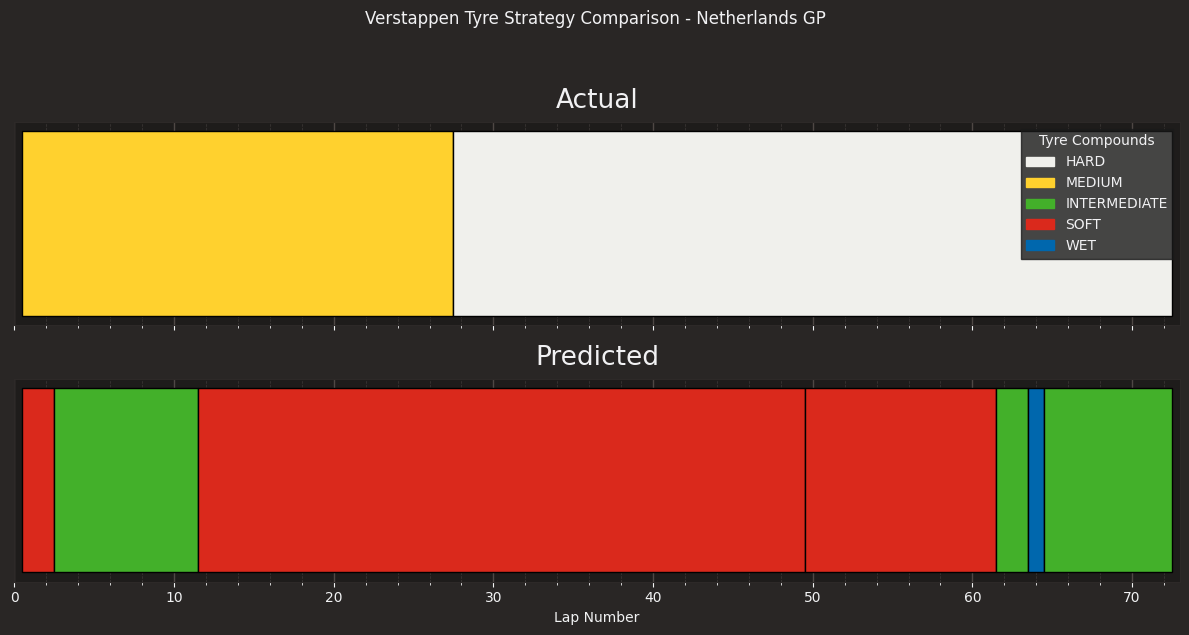

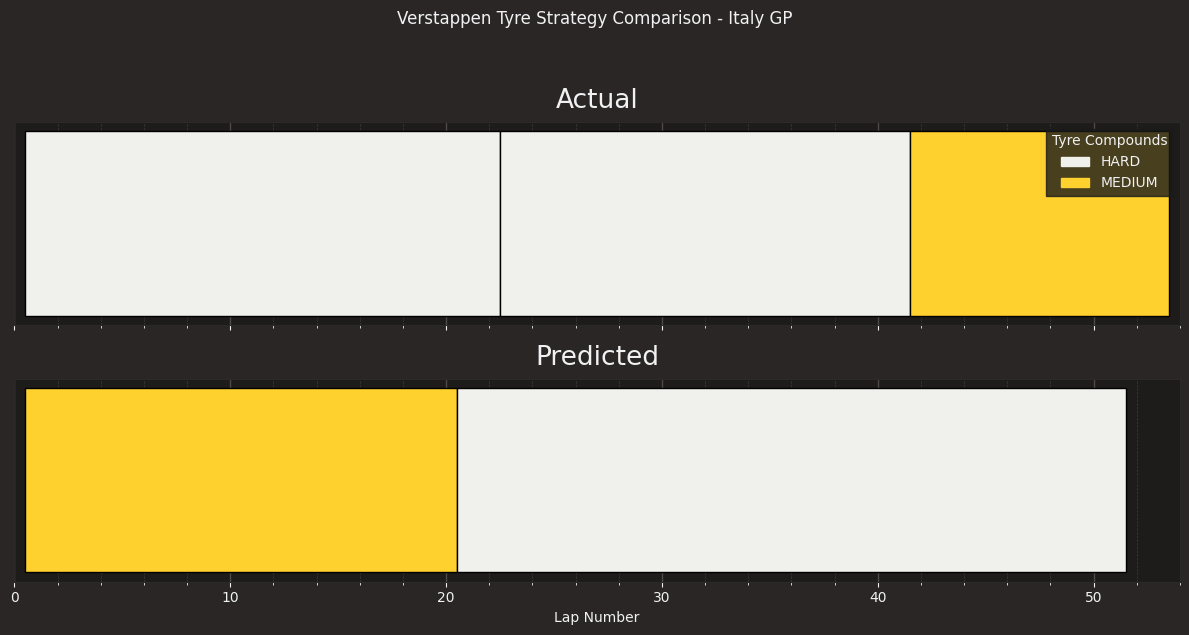

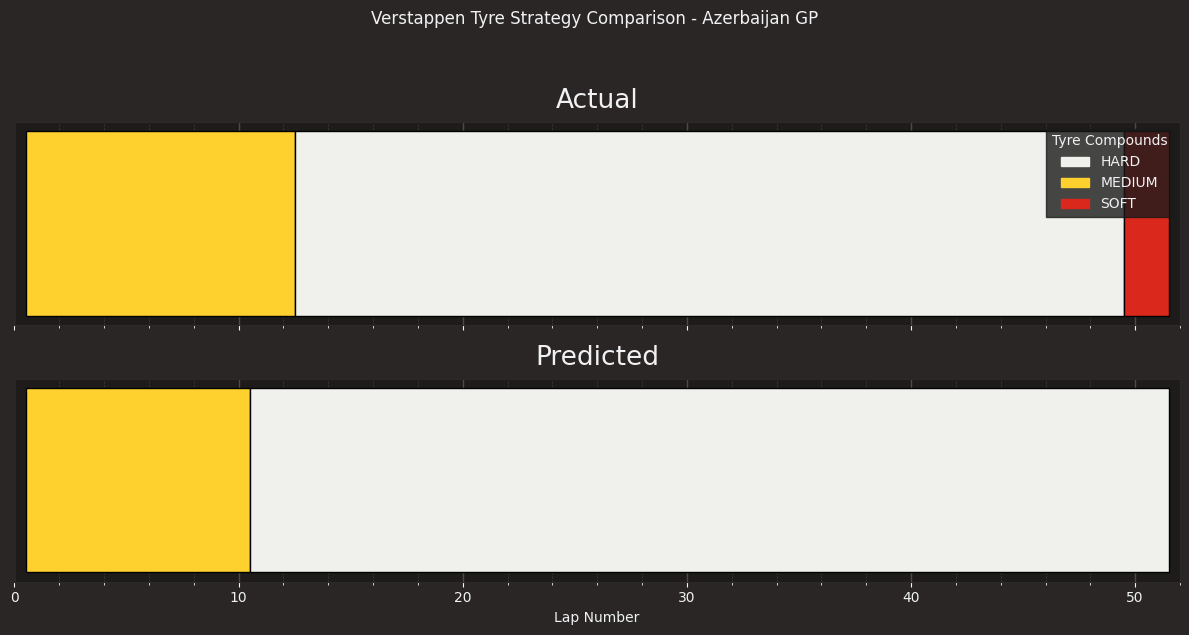

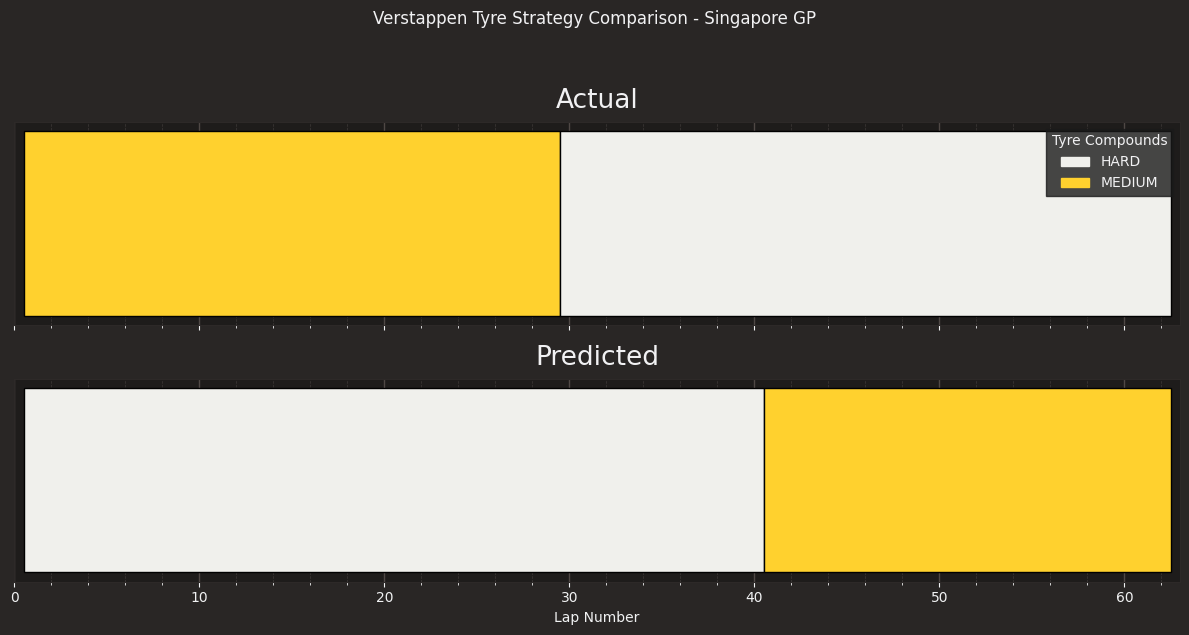

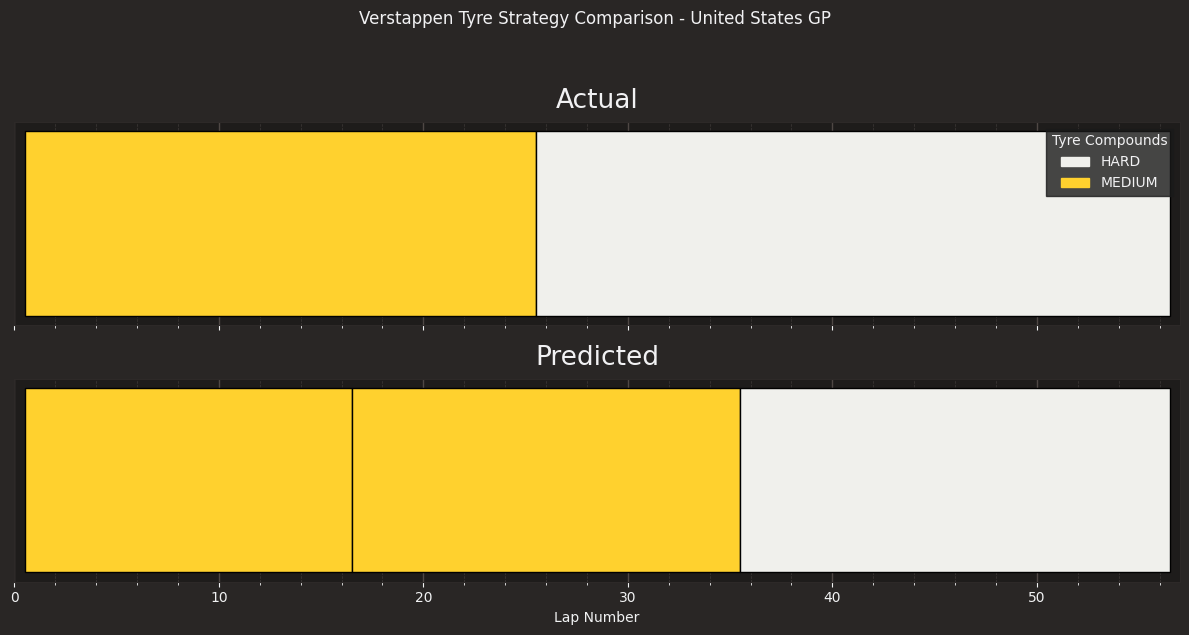

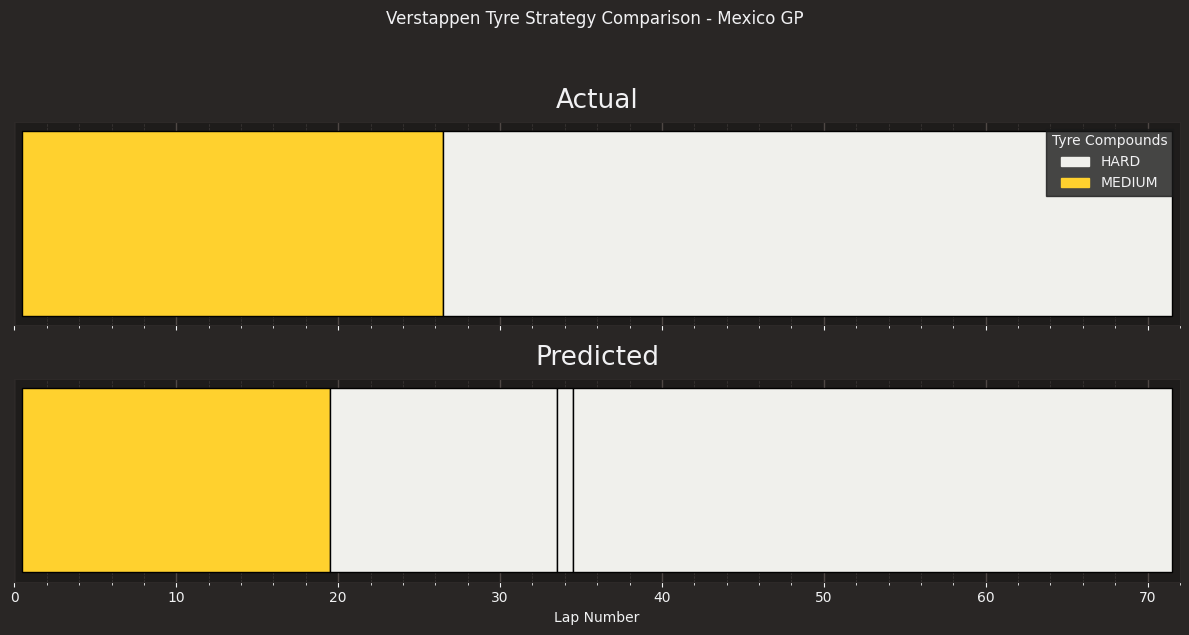

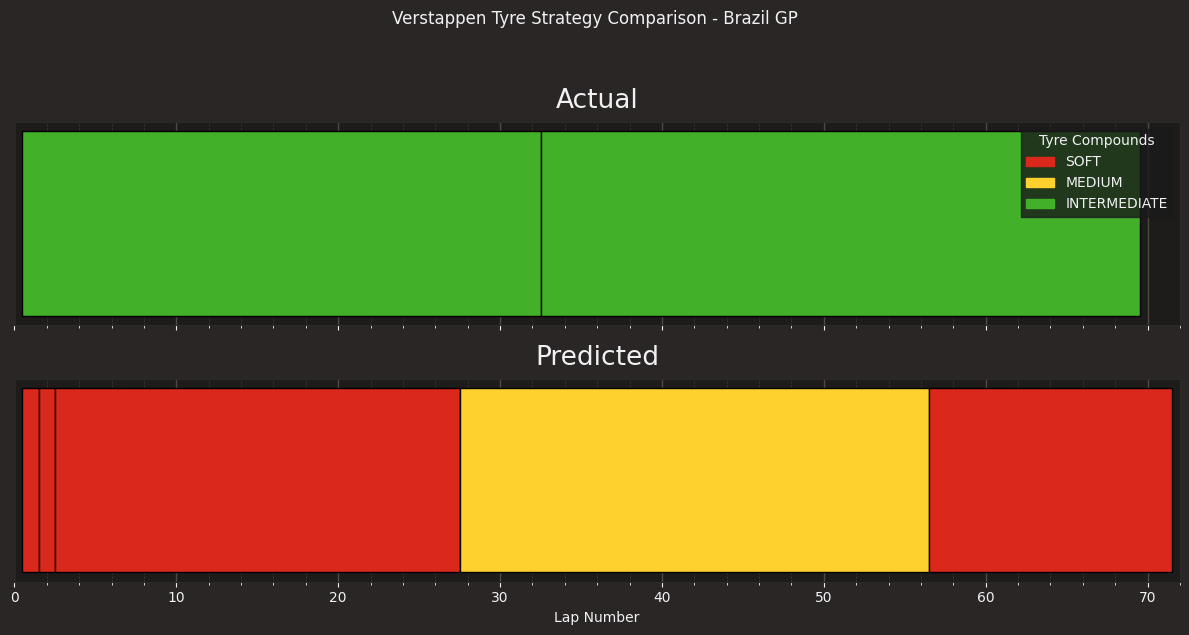

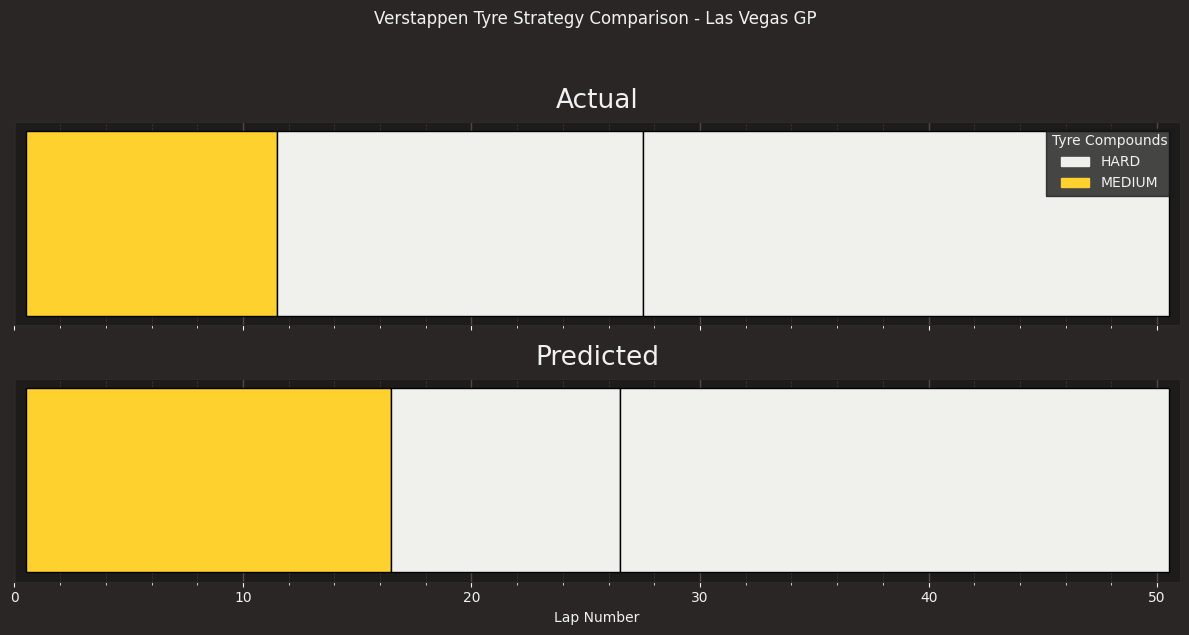

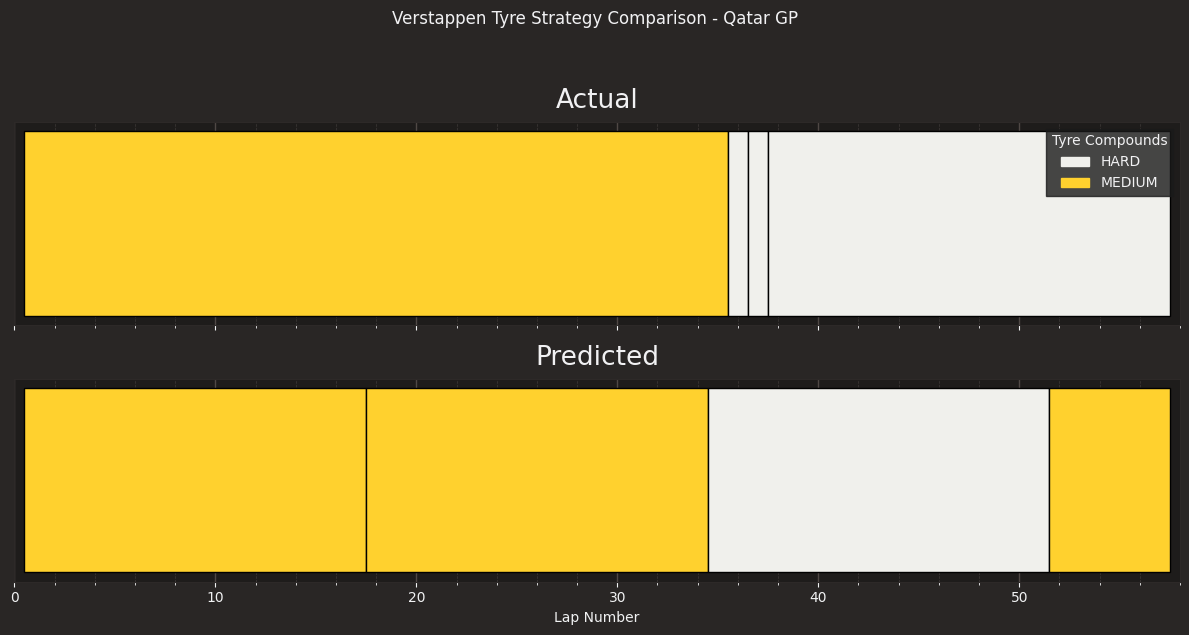

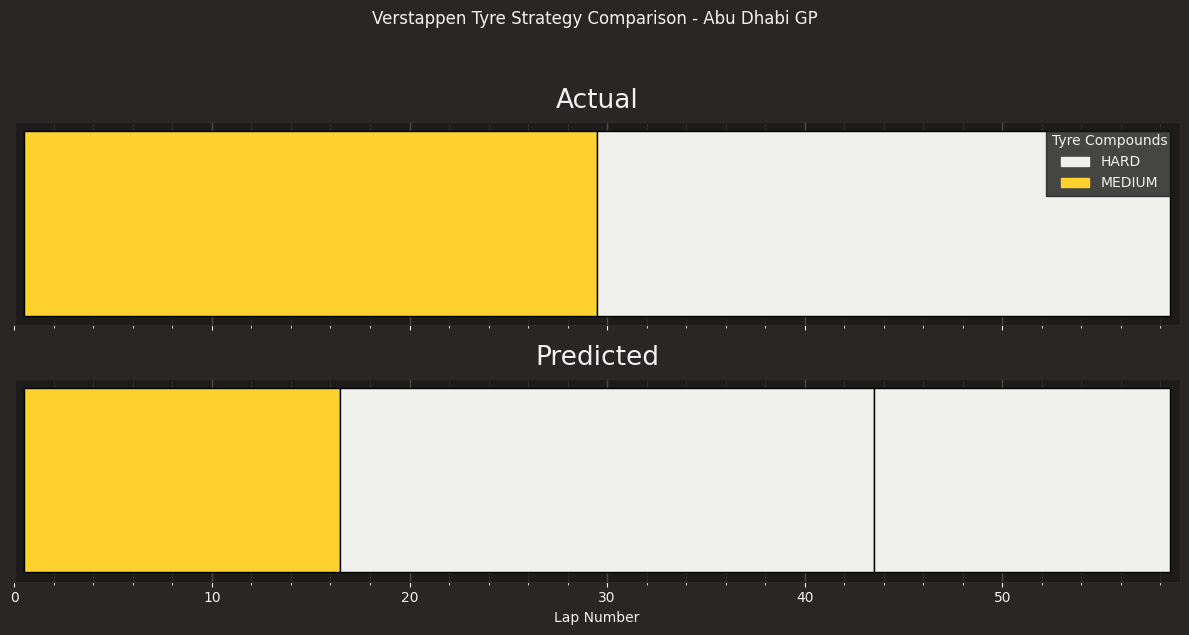

In [ ]:
import fastf1
import fastf1.plotting
import pandas as pd
import matplotlib.pyplot as plt

# Set up FastF1 plotting
fastf1.plotting.setup_mpl()

# List of races to analyze
races = ["Netherlands", "Italy", "Azerbaijan", "Singapore", "United States",
         "Mexico", "Brazil", "Las Vegas", "Qatar", "Abu Dhabi"]

# Dictionary to hold Verstappen's stint data for each race and year
verstappen_data = {}

for race in races:
    verstappen_data[race] = {}
    for year in [2023, 2024]:
        try:
            # Load the race session
            session = fastf1.get_session(year, race, 'R')
            session.load()

            # Get all laps and process stints
            laps = session.laps
            stints = laps[["Driver", "Stint", "Compound", "LapNumber"]]
            stints = stints.groupby(["Driver", "Stint", "Compound"]).agg(
                StintLength=('LapNumber', 'count'),
                StartLap=('LapNumber', 'min'),
                EndLap=('LapNumber', 'max')
            ).reset_index()

            # Filter for Verstappen's stints
            verstappen_stints = stints[stints["Driver"] == "VER"]
            verstappen_data[race][year] = verstappen_stints

        except Exception as e:
            print(f"Error loading {year} {race}: {e}")
            verstappen_data[race][year] = None

# Plotting
for race in races:
    data_2024 = verstappen_data[race].get(2024)
    data_2023 = verstappen_data[race].get(2023)

    # Skip if data is missing or empty
    if data_2024 is None or data_2023 is None:
        print(f"Skipping {race} due to missing data")
        continue
    if data_2024.empty or data_2023.empty:
        print(f"Skipping {race} due to empty data in one year")
        continue

    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    fig.suptitle(f"Verstappen Tyre Strategy Comparison - {race} GP", y=1.05)

    # Plot 2024 stints
    for _, stint in data_2024.iterrows():
        color = fastf1.plotting.COMPOUND_COLORS.get(stint['Compound'], 'grey')
        start = stint['StartLap'] - 0.5
        ax1.barh(0, stint['StintLength'], left=start, color=color, height=0.5, edgecolor='black')

    # Plot 2023 stints
    for _, stint in data_2023.iterrows():
        color = fastf1.plotting.COMPOUND_COLORS.get(stint['Compound'], 'grey')
        start = stint['StartLap'] - 0.5
        ax2.barh(0, stint['StintLength'], left=start, color=color, height=0.5, edgecolor='black')

    # Configure axes
    ax1.set_title("Actual", pad=10)
    ax2.set_title("Predicted", pad=10)
    ax1.set_yticks([])
    ax2.set_yticks([])
    ax2.set_xlabel("Lap Number")

    # Set x-axis limits
    max_lap = max(data_2024['EndLap'].max(), data_2023['EndLap'].max())
    ax1.set_xlim(0, max_lap + 1)

    # Create legend
    compounds = set(data_2024['Compound']).union(set(data_2023['Compound']))
    legend_elements = [
        plt.Rectangle((0,0), 1, 1, color=fastf1.plotting.COMPOUND_COLORS[c])
        for c in compounds if c in fastf1.plotting.COMPOUND_COLORS
    ]
    ax1.legend(legend_elements, compounds, title="Tyre Compounds", loc="upper right")

    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv('ver_Austrian Grand Prix_2023_laps.csv')
df.head()

,LapNumber,LapTime,PitStop,PitTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,...,TrackStatus,Position,TimeGapToLeader,TimeGapToBehind,AirTemp,Humidity,Pressure,TrackTemp,WindDirection,WindSpeed
0,1.0,77.639,False,0.0,NaN,31.613,25.440,292.0,233.0,109.0,...,NaN,1.0,0.0,0,22.1,51.0,934.0,32.0,246,1.2
1,2.0,115.479,True,0.0,31.698,46.293,37.488,176.0,184.0,NaN,...,NaN,1.0,0.0,0,22.3,50.0,934.0,32.1,240,1.1
2,3.0,124.721,False,0.0,37.877,46.298,40.546,191.0,61.0,270.0,...,NaN,1.0,0.0,0,22.5,51.0,934.0,33.0,323,0.6
3,4.0,69.691,False,0.0,17.618,30.970,21.103,293.0,230.0,270.0,...,NaN,1.0,0.0,0,22.7,49.0,934.0,34.3,0,0.0
4,5.0,70.026,False,0.0,17.716,31.158,21.152,285.0,230.0,270.0,...,NaN,1.0,0.0,0,22.8,49.0,934.0,34.3,216,1.1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   LapNumber         58 non-null     float64
 1   LapTime           58 non-null     float64
 2   PitStop           58 non-null     bool   
 3   PitTime           58 non-null     float64
 4   Sector1Time       57 non-null     float64
 5   Sector2Time       58 non-null     float64
 6   Sector3Time       58 non-null     float64
 7   SpeedI1           30 non-null     float64
 8   SpeedI2           58 non-null     float64
 9   SpeedFL           56 non-null     float64
 10  SpeedST           58 non-null     float64
 11  PersonalBestTime  58 non-null     float64
 12  Compound          58 non-null     object 
 13  TyreLife          58 non-null     float64
 14  TrackStatus       49 non-null     float64
 15  Position          58 non-null     float64
 16  TimeGapToLeader   58 non-null     float64
 17 

In [ ]:
df.iloc[0,:]

,0
LapNumber,1.0
LapTime,77.639
PitStop,False
PitTime,0.0
Sector1Time,NaN
Sector2Time,31.613
Sector3Time,25.44
SpeedI1,292.0
SpeedI2,233.0
SpeedFL,109.0
